---
title: "ggnomics: Expression Plots (Violin & Dot)"
format: html
execute:
  echo: true
  warning: false
---

In [2]:
import os
os.chdir("..")
os.getcwd()

'/home/max-nuber/projects/gg_singlecell'

In [3]:
import importlib.util, os
spec = importlib.util.spec_from_file_location("mock_data", os.path.join(os.getcwd(), "examples", "00_mock_data.py"))
mock_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mock_data)

from ggnomics import plot_expression, plot_dot

df    = mock_data.make_mock_df(n_cells=500)
adata = mock_data.make_mock_anndata(n_cells=500)
sce   = mock_data.make_mock_sce(n_cells=500)

FEATURES = ["Gene0001", "Gene0002", "Gene0003", "Gene0051", "Gene0101"]

## 1 — Violin plots (`plot_expression`)

Each feature becomes one facet panel.  The x-axis shows the grouping
variable and the y-axis shows expression level.

### Basic violin — DataFrame

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/02a_violin_df.png


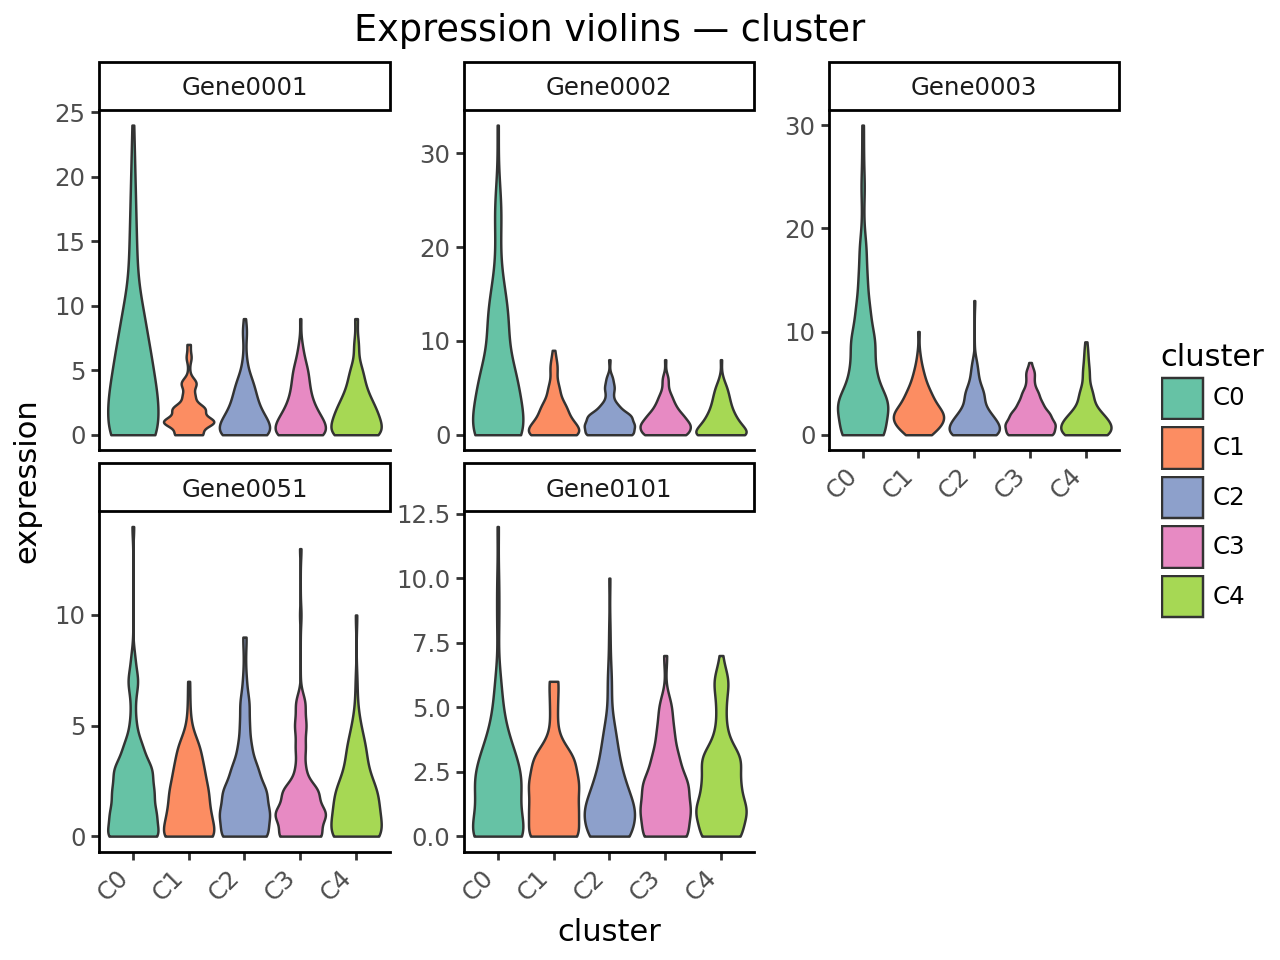

In [4]:
p = plot_expression(df, features=FEATURES, group_by="cluster",
                    title="Expression violins — cluster")
p.save("examples/img/02a_violin_df.png", width=10, height=5, dpi=120)
p

### Log1p-transformed + jittered points

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 9 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/02b_violin_log1p.png


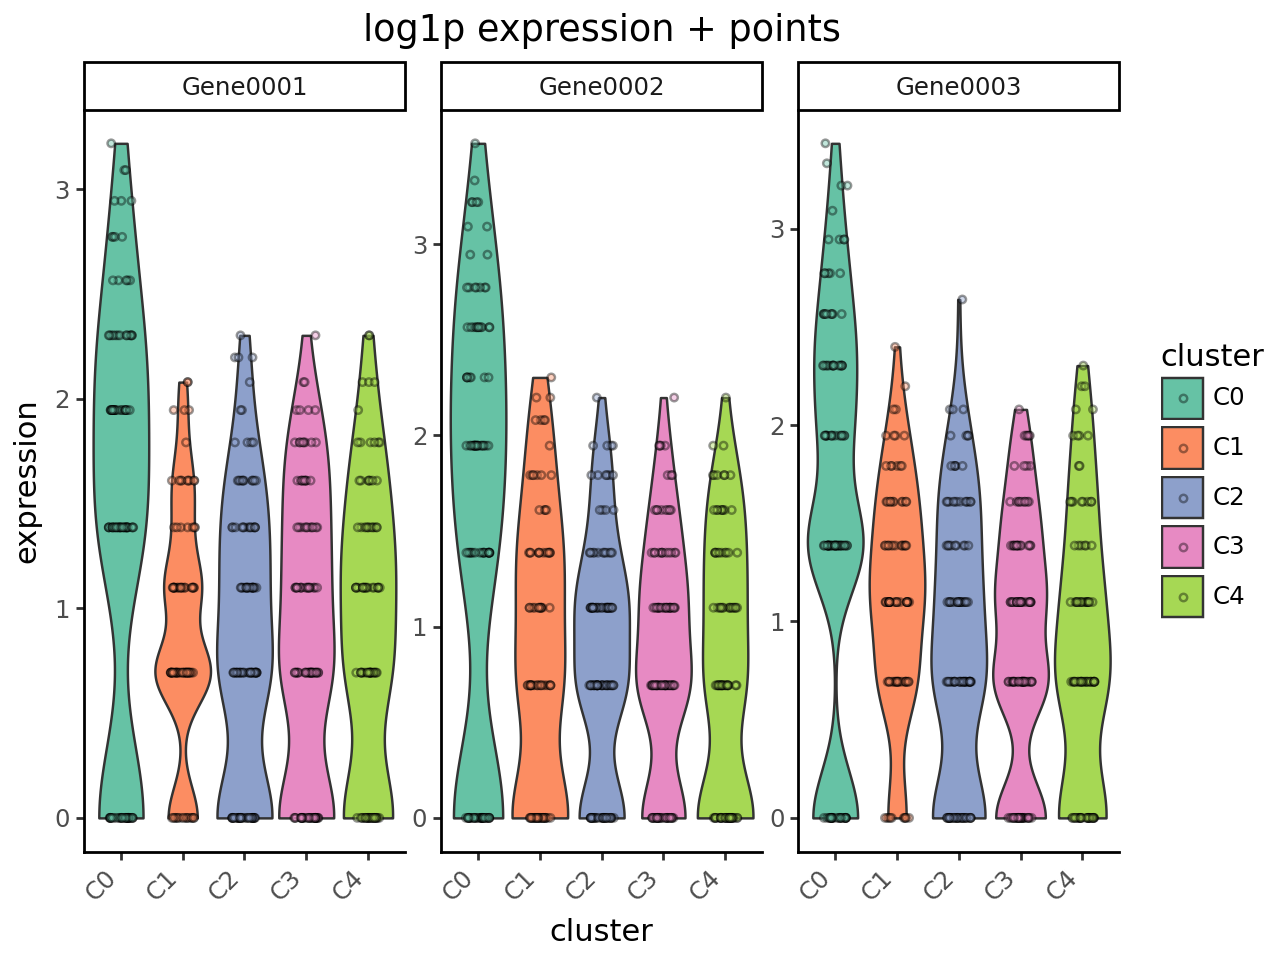

In [5]:
p = plot_expression(df, features=FEATURES[:3], group_by="cluster",
                    log1p=True, add_points=True,
                    title="log1p expression + points")
p.save("examples/img/02b_violin_log1p.png", width=9, height=5, dpi=120)
p

### Colour by a different column (batch)

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 9 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/02c_violin_batch.png


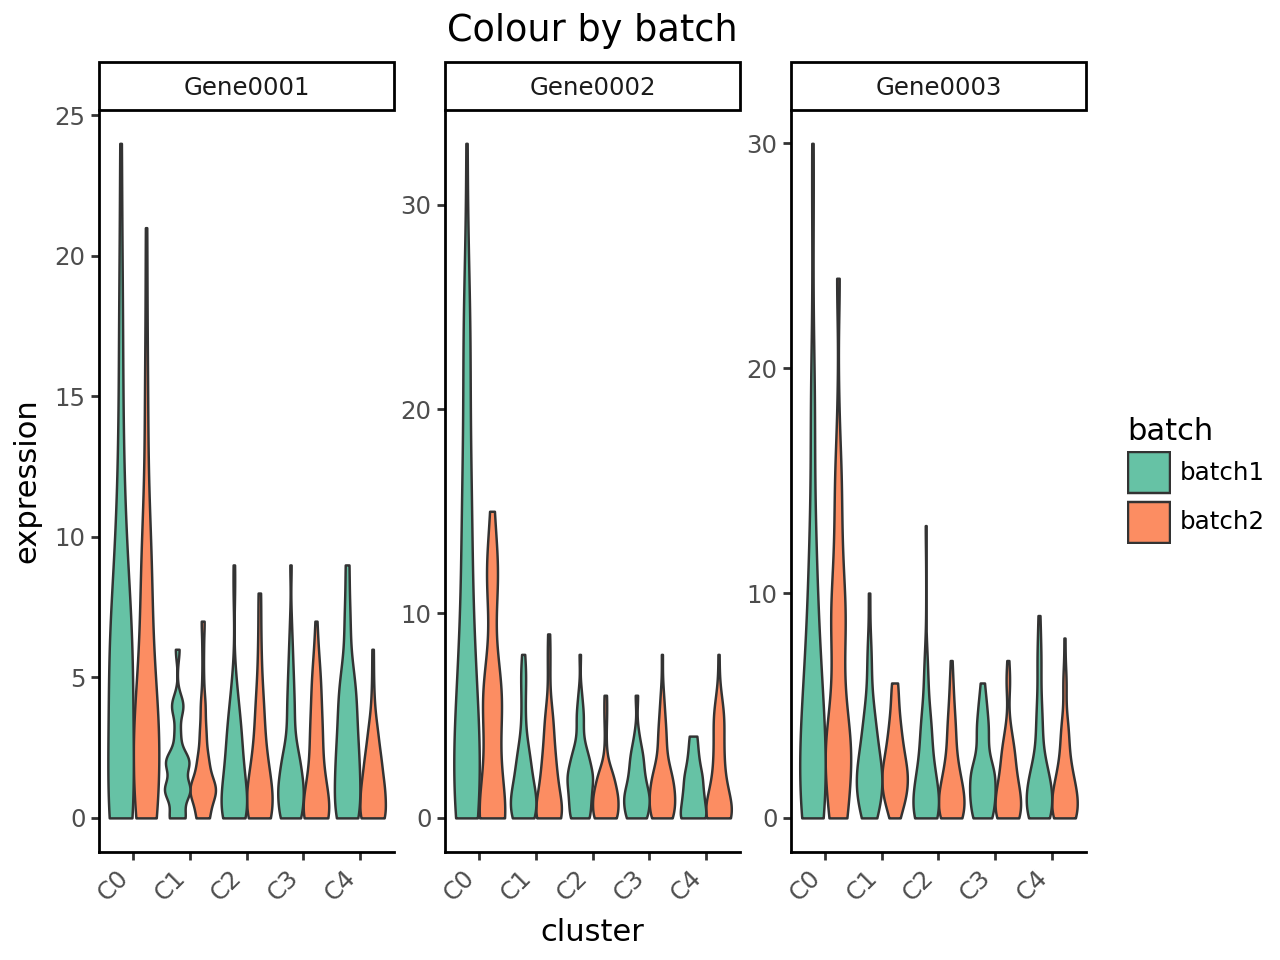

In [6]:
p = plot_expression(df, features=FEATURES[:3], group_by="cluster",
                    color_by="batch", title="Colour by batch")
p.save("examples/img/02c_violin_batch.png", width=9, height=5, dpi=120)
p

### AnnData — logcounts layer

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: examples/img/02d_violin_adata.png


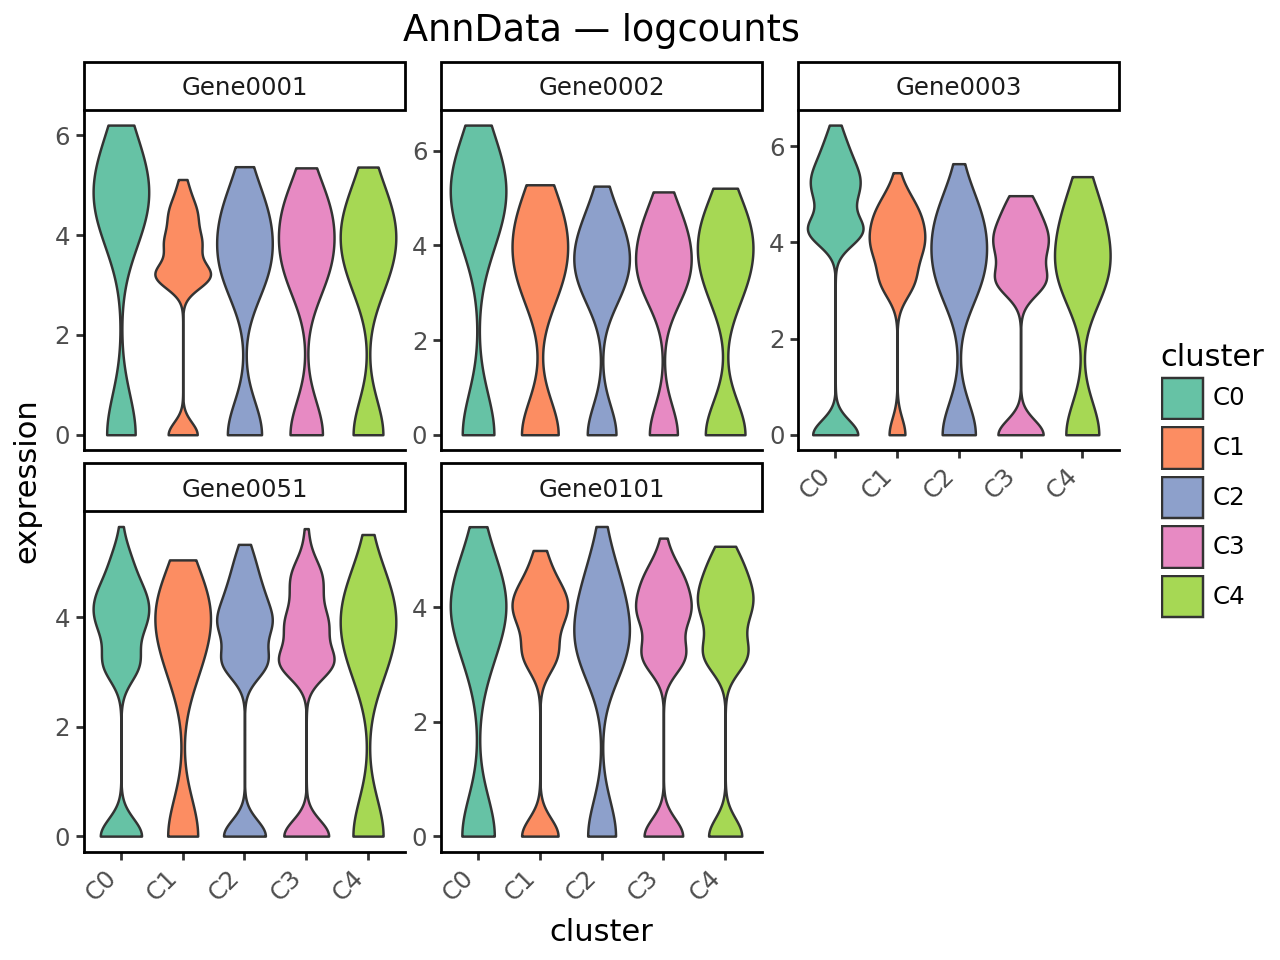

In [7]:
p = plot_expression(adata, features=FEATURES, group_by="cluster",
                    layer="logcounts", title="AnnData — logcounts")
p.save("examples/img/02d_violin_adata.png", width=10, height=5, dpi=120)
p

### SCE

In [ ]:
p = plot_expression(sce, features=FEATURES[:3], group_by="cluster",
                    layer="logcounts", title="SCE — logcounts")
p.save("examples/img/02e_violin_sce.png", width=9, height=5, dpi=120)
p

---

## 2 — Dot plots (`plot_dot`)

Dot size encodes the fraction of cells expressing the gene; dot colour
encodes the mean expression level (scaled by default).

### Basic dot plot

In [ ]:
p = plot_dot(df, features=FEATURES, group_by="cluster",
             title="Dot plot — cluster")
p.save("examples/img/02f_dot_df.png", width=7, height=5, dpi=120)
p

### Unscaled expression

In [ ]:
p = plot_dot(df, features=FEATURES, group_by="cluster", scale=False,
             title="Dot plot — raw expression")
p.save("examples/img/02g_dot_unscaled.png", width=7, height=5, dpi=120)
p

### AnnData / SCE

In [ ]:
p = plot_dot(adata, features=FEATURES, group_by="cluster",
             title="AnnData dot plot")
p.save("examples/img/02h_dot_adata.png", width=7, height=5, dpi=120)
p

---

## Key parameters

### `plot_expression`

| Parameter | Description |
|-----------|-------------|
| `features` | List of gene/feature names |
| `group_by` | Obs column for x-axis grouping |
| `layer` | AnnData layer / SCE assay |
| `color_by` | Obs column to map to fill (default = `group_by`) |
| `log1p` | Log1p-transform before plotting |
| `add_points` | Overlay jittered points |
| `ncol` | Columns in `facet_wrap` layout |

### `plot_dot`

| Parameter | Description |
|-----------|-------------|
| `scale` | Z-scale expression per gene |
| `dot_max/min` | Fraction-expressing dot size range |
| `col_min/max` | Clip scaled expression to these values |
| `palette` | Matplotlib colormap name |